<h3 style='color:purple'>Exercise for k means tutorial</h3>

<img src='iris.png' width=200 height=200>

1. Use iris flower dataset from sklearn library and try to form clusters of flowers using petal width and length features. Drop other two features for simplicity.
2. Figure out if any preprocessing such as scaling would help here
3. Draw elbow plot and from that figure out optimal value of k

In [1]:
from sklearn.datasets import load_iris

iris=load_iris()

In [2]:
import pandas as pd
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
df["flower"]=iris.target

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
df.drop(["sepal length (cm)","sepal width (cm)","flower"],axis="columns",inplace=True)
df.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


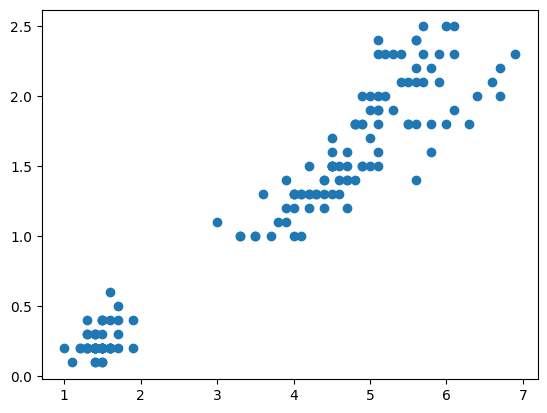

In [7]:
import matplotlib.pyplot as plt

plt.scatter(df["petal length (cm)"],df["petal width (cm)"])

In [9]:
from sklearn.cluster import KMeans

km=KMeans(n_clusters=3)
y_predicted=km.fit_predict(df[["petal length (cm)","petal width (cm)"]])
df["cluster"]=y_predicted


In [10]:
df

,petal length (cm),petal width (cm),cluster
0,1.4,0.2,0
1,1.4,0.2,0
2,1.3,0.2,0
3,1.5,0.2,0
4,1.4,0.2,0
...,...,...,...
145,5.2,2.3,1
146,5.0,1.9,1
147,5.2,2.0,1
148,5.4,2.3,1


In [15]:
df["cluster"]

0      0
1      0
2      0
3      0
4      0
      ..
145    1
146    1
147    1
148    1
149    1
Name: cluster, Length: 150, dtype: int32

In [17]:
cluster1=df[df["cluster"]==0]
cluster2=df[df["cluster"]==1]
cluster3=df[df["cluster"]==2]


In [18]:
len(cluster3)

52

In [19]:
km.cluster_centers_

array([[1.462     , 0.246     ],
       [5.59583333, 2.0375    ],
       [4.26923077, 1.34230769]])

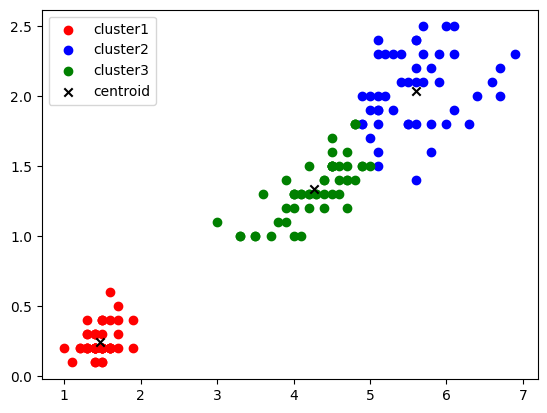

In [21]:
plt.scatter(cluster1["petal length (cm)"],cluster1["petal width (cm)"],color="red",label="cluster1")
plt.scatter(cluster2["petal length (cm)"],cluster2["petal width (cm)"],color="blue",label="cluster2")
plt.scatter(cluster3["petal length (cm)"],cluster3["petal width (cm)"],color="green",label="cluster3")
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color="black",marker="x",label="centroid")
plt.legend()
plt.show()

**Elbow Plot**

In [22]:
df.head()

,petal length (cm),petal width (cm),cluster
0,1.4,0.2,0
1,1.4,0.2,0
2,1.3,0.2,0
3,1.5,0.2,0
4,1.4,0.2,0


In [24]:
df.drop(["cluster"],axis="columns",inplace=True)
df.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


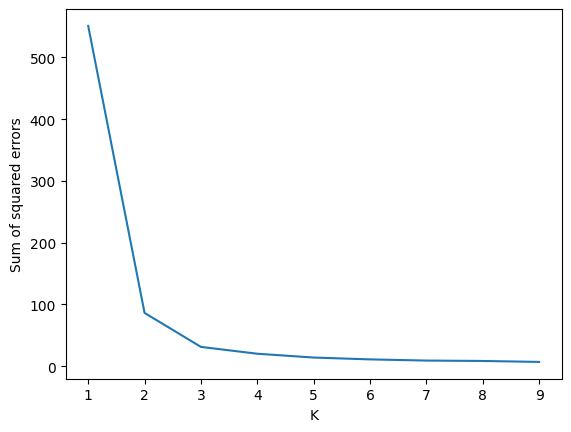

In [25]:
sse=[]
k_rng=range(1,10)
for k in k_rng:
    km=KMeans(n_clusters=k)
    km.fit(df)
    sse.append(km.inertia_)


plt.xlabel("K")
plt.ylabel("Sum of squared errors")
plt.plot(k_rng,sse)

#  k=2 was the correct